In [2]:
using PKAssetPrices.Dynamic: DynamicModel, DiscreteTime, DynamicParametrization, solve_model, @model
using PKAssetPrices
using CairoMakie

In [2]:
sol_αQCr =  solve_model(Dynamic.DynαQCr)
sol_αQC =  solve_model(Dynamic.DynαQC)
sol_αQ = solve_model(Dynamic.DynαQ)
sol_α = solve_model(Dynamic.Dynα)
sol_Q = solve_model(Dynamic.DynQ)

PKAssetPrices.Dynamic.DynamicSolution{PKAssetPrices.Dynamic.var"#36#37", PKAssetPrices.Dynamic.var"#38#39"}(DynamicParametrization{PKAssetPrices.Dynamic.var"#36#37", PKAssetPrices.Dynamic.var"#38#39"}(DynamicModel{PKAssetPrices.Dynamic.var"#36#37", PKAssetPrices.Dynamic.var"#38#39"}(DiscreteTime([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]), PKAssetPrices.Dynamic.DynVar[PKAssetPrices.Dynamic.DynVar(:Y, "Output"), PKAssetPrices.Dynamic.DynVar(:ND, "Non debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:D, "debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:i, "policy rate"), PKAssetPrices.Dynamic.DynVar(:r, "interest rate"), PKAssetPrices.Dynamic.DynVar(:P, "price level"), PKAssetPrices.Dynamic.DynVar(:dL, "change in loans"), PKAssetPrices.Dynamic.DynVar(:dM, "change in money"), PKAssetPrices.Dynamic.DynVar(:dR, "change in reserves"), PKAssetPrices.Dynamic.DynVar(:W, "wage level"), PKAssetPrices.Dynamic.DynVar(:

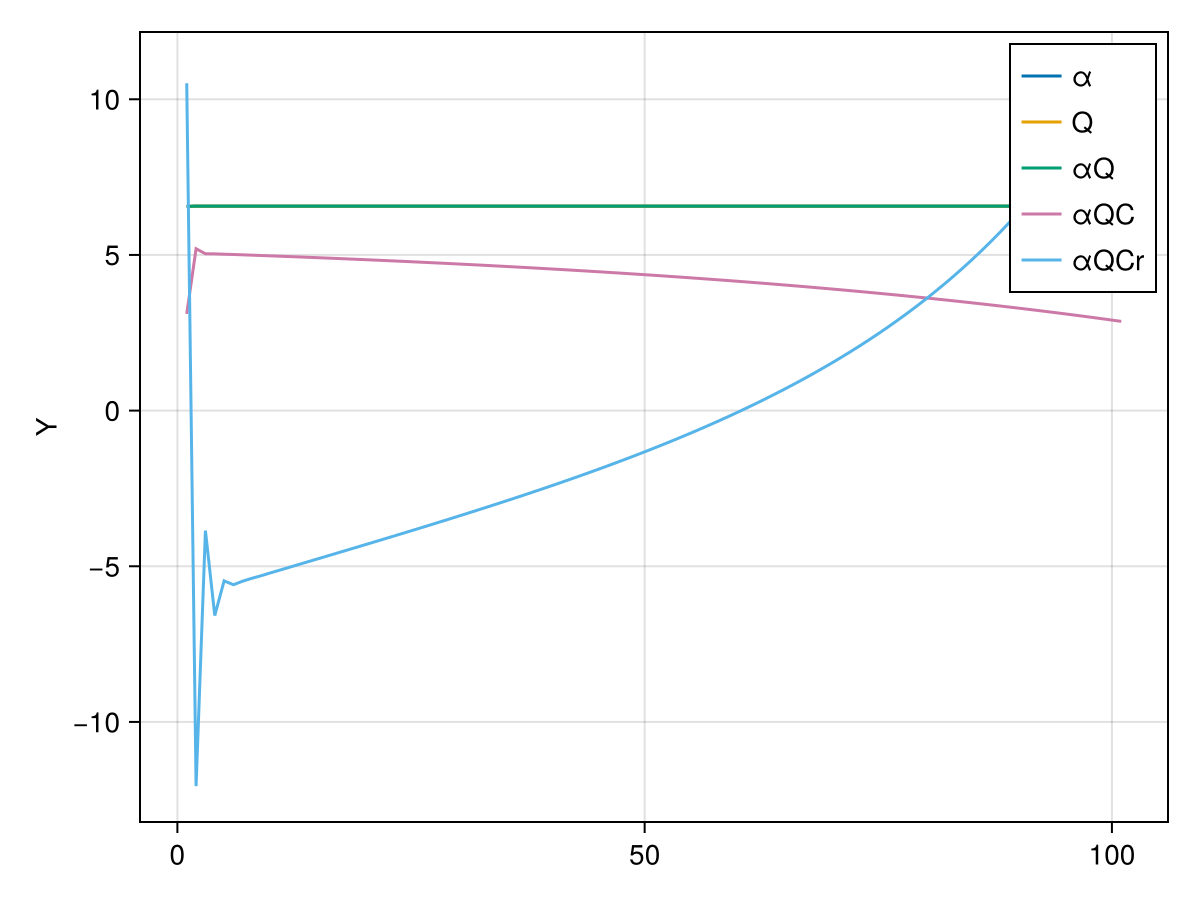

In [3]:
f = Figure()
ax = Axis(f[1,1], ylabel= "Y")
lines!(ax,sol_α.paths[:Y], label = "α")
lines!(ax, sol_Q.paths[:Y], label = "Q")
lines!(ax, sol_αQ.paths[:Y], label = "αQ")
lines!(ax, sol_αQC.paths[:Y], label = "αQC")
lines!(ax, sol_αQCr.paths[:Y], label = "αQCr")
axislegend(ax)
f

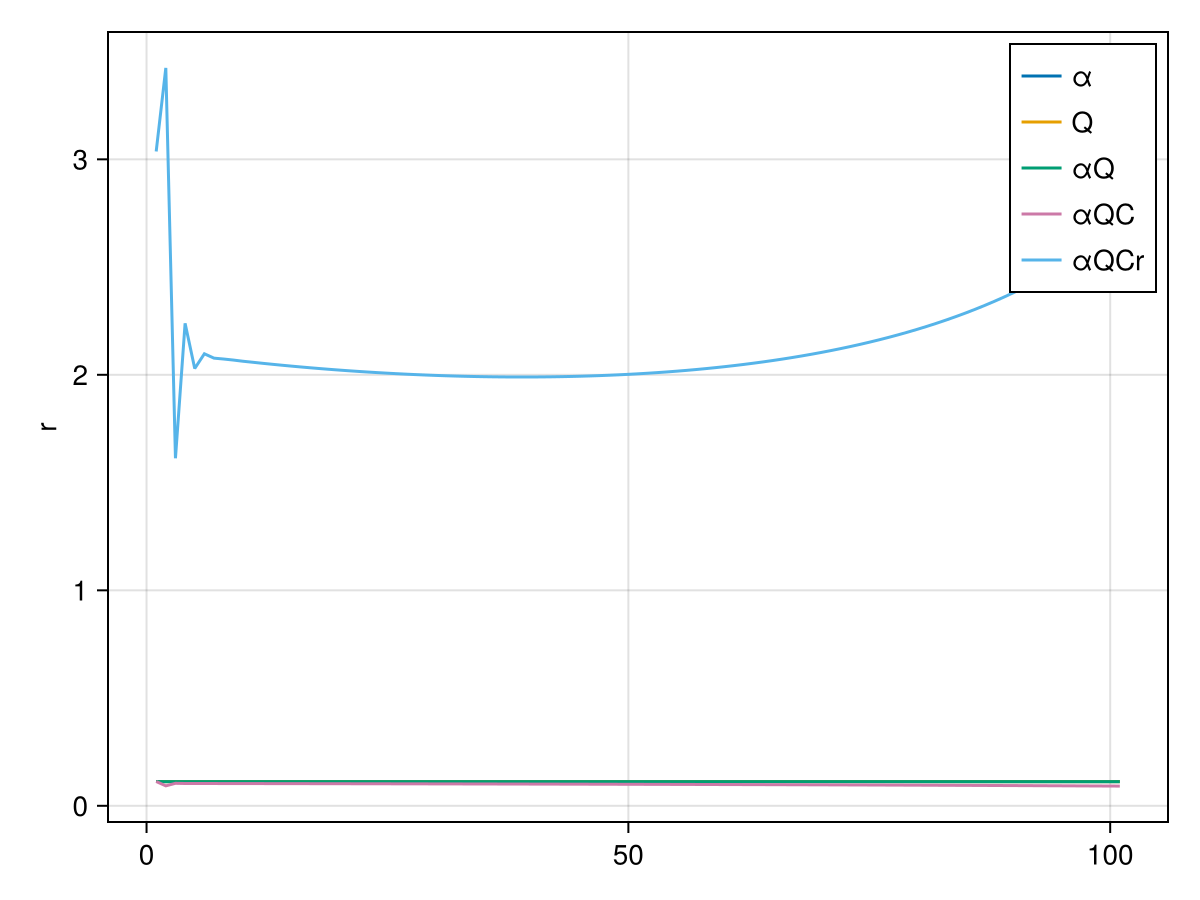

In [4]:
f = Figure()
ax = Axis(f[1,1], ylabel= "r")
lines!(ax,sol_α.paths[:r], label = "α")
lines!(ax, sol_Q.paths[:r], label = "Q")
lines!(ax, sol_αQ.paths[:r], label = "αQ")
lines!(ax, sol_αQC.paths[:r], label = "αQC")
lines!(ax, sol_αQCr.paths[:r], label = "αQCr")
axislegend(ax)
f

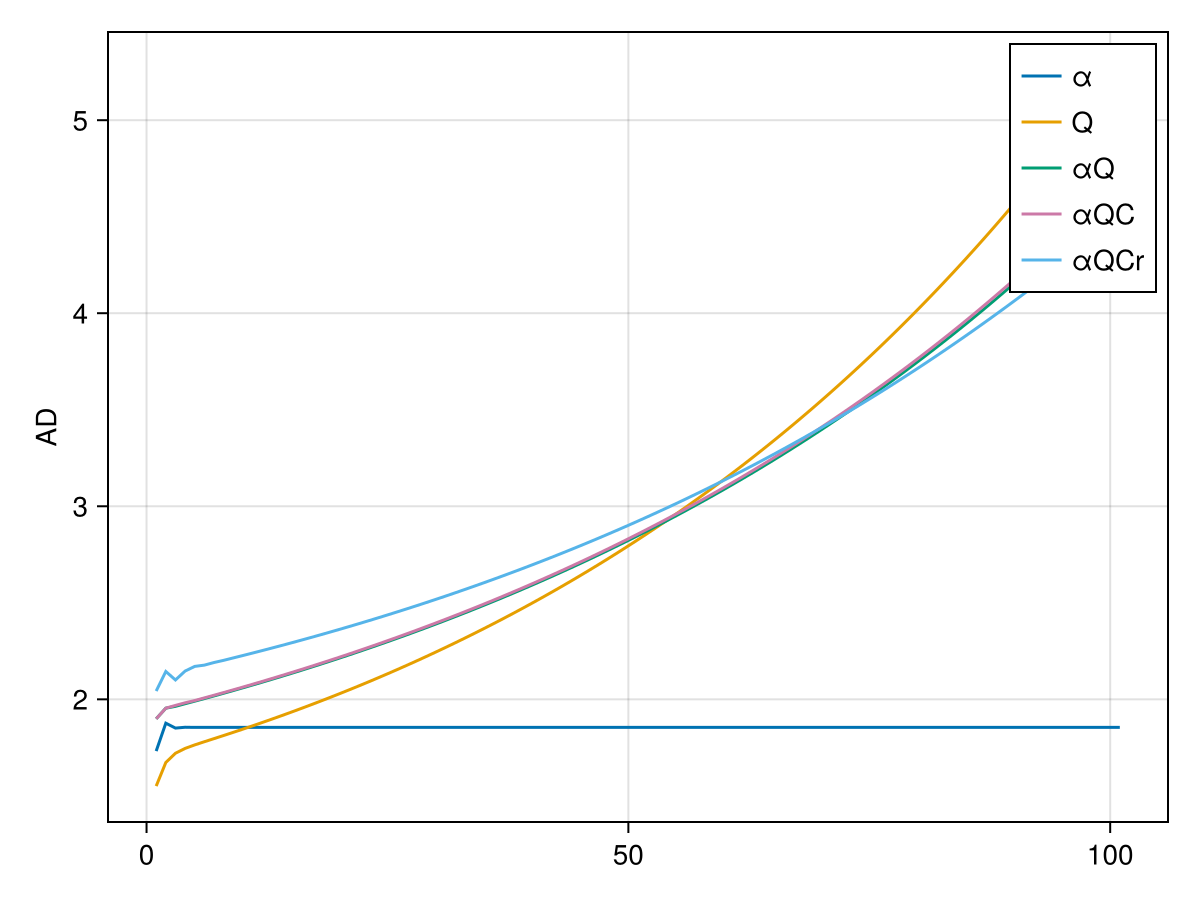

In [5]:
f = Figure()
ax = Axis(f[1,1], ylabel="AD")
lines!(ax,sol_α.paths[:AD], label = "α")
lines!(ax, sol_Q.paths[:AD], label = "Q")
lines!(ax, sol_αQ.paths[:AD], label = "αQ")
lines!(ax, sol_αQC.paths[:AD], label = "αQC")
lines!(ax, sol_αQCr.paths[:AD], label = "αQCr")
axislegend(ax)
f

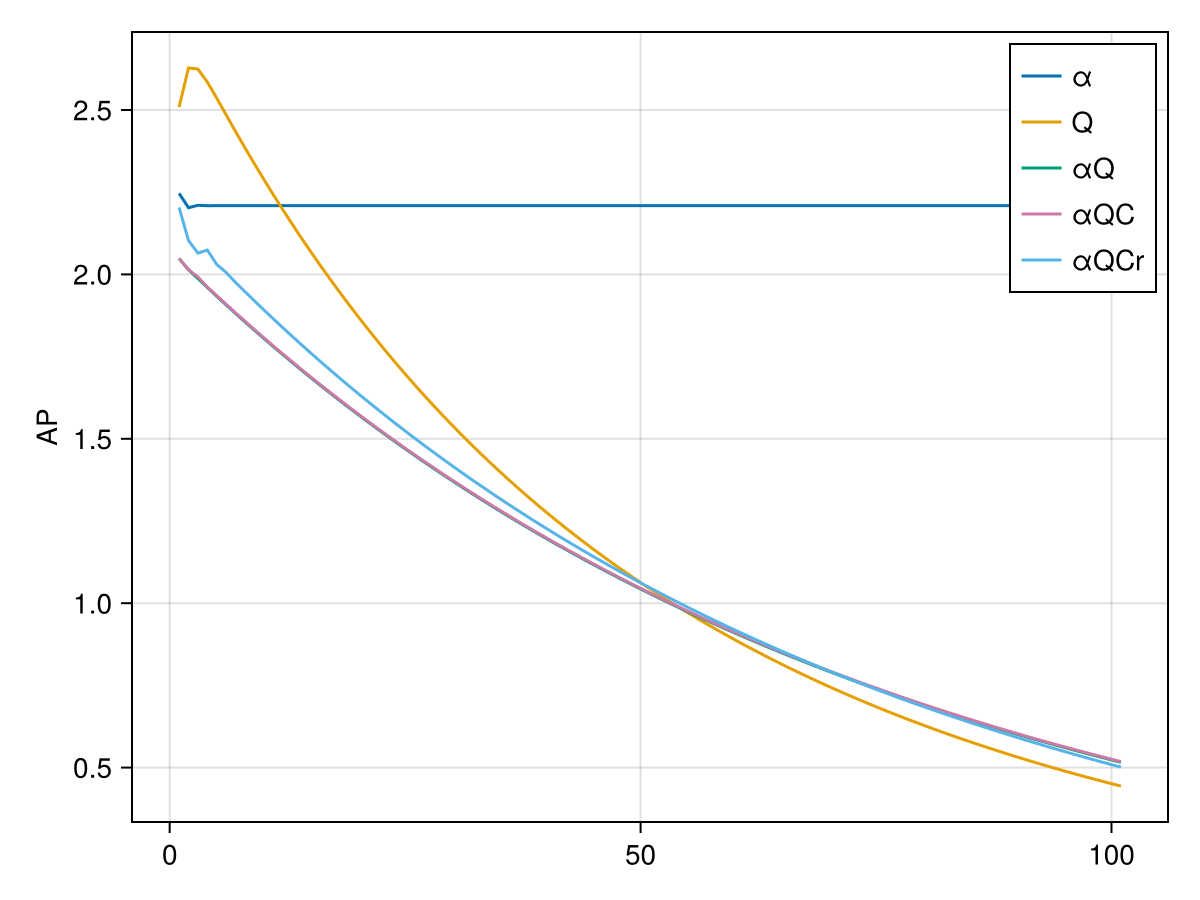

In [6]:

f = Figure()
ax = Axis(f[1,1], ylabel = "AP")
lines!(ax,sol_α.paths[:AP], label = "α")
lines!(ax, sol_Q.paths[:AP], label = "Q")
lines!(ax, sol_αQ.paths[:AP], label = "αQ")
lines!(ax, sol_αQC.paths[:AP], label = "αQC")
lines!(ax, sol_αQCr.paths[:AP], label = "αQCr")
axislegend(ax)
f

In [20]:
function eval_model(x, p)
    model = deepcopy(p)
    model.params[:c₀] = x[1]
    model.params[:c₁] = x[2]
    model.params[:i0] = x[3]
    model.params[:i1] = x[4]
    model.params[:i2] = x[5]
    model.params[:s0] = x[6]
    model.params[:s1] = x[7]
    model.params[:s2] = x[8]
    model.params[:γ] = x[9]
    model.params[:α] = x[10]

    sol = Dynamic.solve_model(model)

    return sol
end



eval_model (generic function with 1 method)

In [105]:
x1 = [0.5548930679984638, 0.037493422061853576, 0.0010338977168088952, 0.003911292531920632, 0.11548465017702524, 0.17509632134056813, 0.21079893916816597, 0.09448254710928712, 0.6241246752385647, 0.044024262656295665]

10-element Vector{Float64}:
 0.5548930679984638
 0.037493422061853576
 0.0010338977168088952
 0.003911292531920632
 0.11548465017702524
 0.17509632134056813
 0.21079893916816597
 0.09448254710928712
 0.6241246752385647
 0.044024262656295665

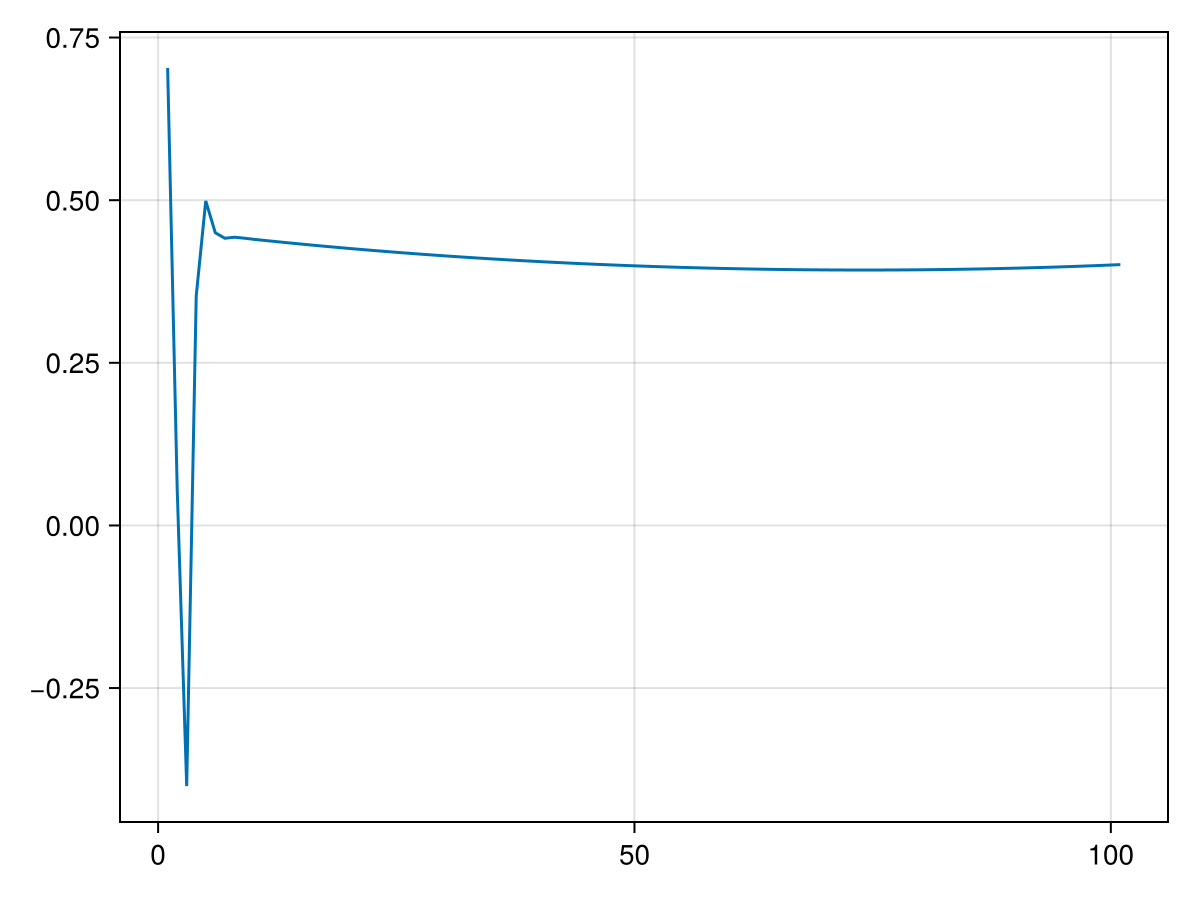

In [108]:
lines(eval_model(x1,Dynamic.DynαQCr).paths[:U])